In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [13]:
df = pd.read_csv("salary.csv", low_memory=False)

In [14]:
pd.set_option("display.max_columns", None)

In [15]:
df.head()

,AGENCY,AGENCY NAME,LAST NAME,FIRST NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,EMPLOY DATE,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,STATE NUMBER,duplicated,multiple_full_time_jobs,combined_multiple_jobs,summed_annual_salary,hide_from_search
0,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",RUCKER,MORTON,V,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,02/18/88,75.96150,29.0,9545.82,114549.84,127717,True,NaN,NaN,131407.08,NaN
1,212,OFFICE OF COURT ADMINISTRATION ...,RUCKER,MORTON,V,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,02/01/15,81.04454,4.0,1404.77,16857.24,127717,True,NaN,NaN,NaN,True
2,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",SPECIA JR,JOHN,J,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,02/01/20,75.96150,29.0,9545.82,114549.84,59115,True,NaN,NaN,131407.08,NaN
3,212,OFFICE OF COURT ADMINISTRATION ...,SPECIA JR,JOHN,J,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,09/01/18,81.04453,4.0,1404.77,16857.24,59115,True,NaN,NaN,NaN,True
4,696,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,ONTIVEROS,ESTHER,,4504,CORREC OFFICER IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,06/29/20,0.00000,40.0,3284.27,39411.24,165030,True,1.0,NaN,NaN,NaN


In [16]:
df.shape

(149481, 21)

- **The dataset contains 149481 rows and 21 columns, representing employee payroll records for the state of Texas.**

In [17]:
df.columns

Index(['AGENCY', 'AGENCY NAME', 'LAST NAME', 'FIRST NAME', 'MI', 'CLASS CODE',
       'CLASS TITLE', 'ETHNICITY', 'GENDER', 'STATUS', 'EMPLOY DATE',
       'HRLY RATE', 'HRS PER WK', 'MONTHLY', 'ANNUAL', 'STATE NUMBER',
       'duplicated', 'multiple_full_time_jobs', 'combined_multiple_jobs',
       'summed_annual_salary', 'hide_from_search'],
      dtype='object')

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149481 entries, 0 to 149480
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   AGENCY                   149481 non-null  int64  
 1   AGENCY NAME              149481 non-null  object 
 2   LAST NAME                149481 non-null  object 
 3   FIRST NAME               149481 non-null  object 
 4   MI                       149481 non-null  object 
 5   CLASS CODE               149481 non-null  object 
 6   CLASS TITLE              149481 non-null  object 
 7   ETHNICITY                149481 non-null  object 
 8   GENDER                   149481 non-null  object 
 9   STATUS                   149481 non-null  object 
 10  EMPLOY DATE              149481 non-null  object 
 11  HRLY RATE                149481 non-null  float64
 12  HRS PER WK               149481 non-null  float64
 13  MONTHLY                  149481 non-null  float64
 14  ANNU

In [19]:
df.isnull().sum().sort_values(ascending=False)

multiple_full_time_jobs    149467
summed_annual_salary       149465
hide_from_search           149465
combined_multiple_jobs     149384
duplicated                 149338
MI                              0
FIRST NAME                      0
LAST NAME                       0
AGENCY NAME                     0
AGENCY                          0
CLASS CODE                      0
ETHNICITY                       0
CLASS TITLE                     0
HRS PER WK                      0
HRLY RATE                       0
EMPLOY DATE                     0
STATUS                          0
GENDER                          0
STATE NUMBER                    0
MONTHLY                         0
ANNUAL                          0
dtype: int64

In [20]:
(df.isnull().mean() * 100).sort_values(ascending=False)

multiple_full_time_jobs    99.990634
summed_annual_salary       99.989296
hide_from_search           99.989296
combined_multiple_jobs     99.935109
duplicated                 99.904336
MI                          0.000000
FIRST NAME                  0.000000
LAST NAME                   0.000000
AGENCY NAME                 0.000000
AGENCY                      0.000000
CLASS CODE                  0.000000
ETHNICITY                   0.000000
CLASS TITLE                 0.000000
HRS PER WK                  0.000000
HRLY RATE                   0.000000
EMPLOY DATE                 0.000000
STATUS                      0.000000
GENDER                      0.000000
STATE NUMBER                0.000000
MONTHLY                     0.000000
ANNUAL                      0.000000
dtype: float64

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
data = df.drop(columns=["FIRST NAME", "LAST NAME", "MI", "STATE NUMBER", "multiple_full_time_jobs", "summed_annual_salary","hide_from_search","combined_multiple_jobs","duplicated"], axis=1)

In [23]:
data.head()

,AGENCY,AGENCY NAME,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,EMPLOY DATE,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL
0,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,02/18/88,75.96150,29.0,9545.82,114549.84
1,212,OFFICE OF COURT ADMINISTRATION ...,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,02/01/15,81.04454,4.0,1404.77,16857.24
2,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,02/01/20,75.96150,29.0,9545.82,114549.84
3,212,OFFICE OF COURT ADMINISTRATION ...,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,09/01/18,81.04453,4.0,1404.77,16857.24
4,696,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,4504,CORREC OFFICER IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,06/29/20,0.00000,40.0,3284.27,39411.24


**We dropped the**
- **"multiple_full_time_jobs",**
- **"summed_annual_salary"**,
- **"hide_from_search",**
- **"combined_multiple_jobs" and**
- **"duplicated"**

**columns because they contain more than 99% of missing values.**

**Personally identifiable information such as employee names and state numbers were removed as they do not contribute to salary prediction.**

In [24]:
data['EMPLOY DATE'] = pd.to_datetime(data['EMPLOY DATE'], errors='coerce')

In [25]:
current_year = pd.Timestamp.now().year

data['experience_years'] = current_year - data['EMPLOY DATE'].dt.year

In [26]:
data.loc[data['experience_years'] < 0, 'experience_years'] = np.nan

In [27]:
data["experience_years"].isnull().sum()

np.int64(8)

**First we converted the 'EMPLOY DATE' column in a proper format and after that using the same columm we created a column called 'experience_years' beacuse employees with higher experience generally have higher salaries.**

In [28]:
data[data["experience_years"].isnull()]

,AGENCY,AGENCY NAME,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,EMPLOY DATE,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,experience_years
1825,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,2075-09-01,75.9615,29.0,9545.82,114549.84,NaN
20904,405,DEPARTMENT OF PUBLIC SAFETY ...,9940,"SERGEANT, DPS ...",WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,2071-10-06,0.0000,40.0,7207.91,86494.92,NaN
88771,601,TEXAS DEPARTMENT OF TRANSPORTATION ...,0152,ADMINISTRATIVE ASST II ...,WHITE,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,2072-08-01,0.0000,40.0,3388.44,40661.28,NaN
92736,601,TEXAS DEPARTMENT OF TRANSPORTATION ...,1572,PROGRAM SPECIALIST III ...,WHITE,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,2073-09-10,0.0000,40.0,5733.00,68796.00,NaN
116978,696,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,4675,AGRICULTURE SPEC V ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,2069-07-14,0.0000,40.0,4033.74,48404.88,NaN
141891,102,HOUSE OF REPRESENTATIVES ...,7109,ELECTED OFFICIAL ...,WHITE,MALE,URF - UNCLASSIFIED REGULAR FULL-TIME,2069-01-14,0.0000,40.0,600.00,7200.00,NaN
142425,102,HOUSE OF REPRESENTATIVES ...,7109,ELECTED OFFICIAL ...,BLACK,FEMALE,URF - UNCLASSIFIED REGULAR FULL-TIME,2073-01-09,0.0000,40.0,600.00,7200.00,NaN
148921,592,SOIL AND WATER CONSERVATION BOARD ...,1576,PROGRAM SPECIALIST VII ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,2068-12-01,0.0000,40.0,7658.41,91900.92,NaN


In [29]:
data['experience_years'].fillna(data['experience_years'].median(), inplace=True)

In [30]:
data.isnull().sum().sort_values(ascending=False)

AGENCY              0
AGENCY NAME         0
CLASS CODE          0
CLASS TITLE         0
ETHNICITY           0
GENDER              0
STATUS              0
EMPLOY DATE         0
HRLY RATE           0
HRS PER WK          0
MONTHLY             0
ANNUAL              0
experience_years    0
dtype: int64

In [31]:
data.describe()

,AGENCY,EMPLOY DATE,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,experience_years
count,149481.000000,149481,149481.000000,149481.000000,149481.000000,149481.000000,149481.000000
mean,545.736288,2014-01-14 00:53:14.605334272,0.346488,39.714918,4226.184248,50714.210973,12.458179
min,101.000000,1976-03-15 00:00:00,0.000000,1.000000,50.000000,600.000000,6.000000
25%,529.000000,2010-12-20 00:00:00,0.000000,40.000000,3019.840000,36238.080000,8.000000
50%,530.000000,2016-10-10 00:00:00,0.000000,40.000000,3720.170000,44642.040000,10.000000
75%,696.000000,2018-12-03 00:00:00,0.000000,40.000000,4865.810000,58389.720000,16.000000
max,930.000000,2075-09-01 00:00:00,117.788480,70.000000,46125.000000,553500.000000,50.000000
std,139.057691,NaN,4.211485,2.323855,2093.111691,25117.340292,6.791213


In [32]:
data.columns

Index(['AGENCY', 'AGENCY NAME', 'CLASS CODE', 'CLASS TITLE', 'ETHNICITY',
       'GENDER', 'STATUS', 'EMPLOY DATE', 'HRLY RATE', 'HRS PER WK', 'MONTHLY',
       'ANNUAL', 'experience_years'],
      dtype='object')

# Exploratory Data Analysis - EDA

## Uni-Variate Analysis

### AGENCY NAME

In [33]:
data["AGENCY NAME"].value_counts().head(10)

AGENCY NAME
HEALTH AND HUMAN SERVICES COMMISSION                  36667
TEXAS DEPARTMENT OF CRIMINAL JUSTICE                  35926
TEXAS DEPARTMENT OF TRANSPORTATION                    13099
DEPARTMENT OF FAMILY AND PROTECTIVE SERVICES          12588
DEPARTMENT OF PUBLIC SAFETY                           10097
TEXAS WORKFORCE COMMISSION                             4653
OFFICE OF THE ATTORNEY GENERAL                         4141
DEPARTMENT OF STATE HEALTH SERVICES                    3129
PARKS AND WILDLIFE DEPARTMENT                          3060
COMPTROLLER OF PUBLIC ACCOUNTS                         2748
Name: count, dtype: int64

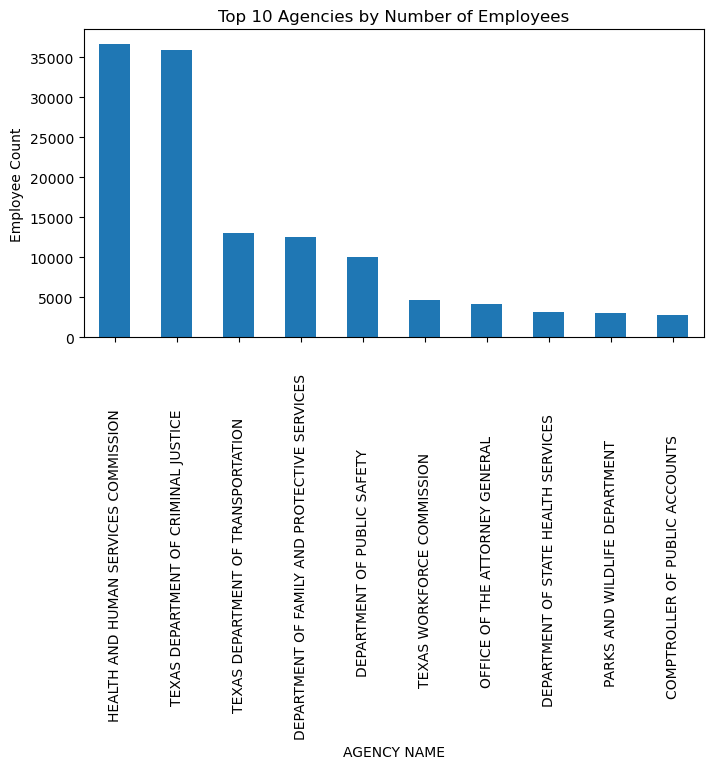

In [34]:
plt.figure(figsize=(8,4))
data['AGENCY NAME'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Agencies by Number of Employees")
plt.ylabel("Employee Count")
plt.show()

**Here we can see that the majority of employees are working in HEALTH AND HUMAN SERVICES COMMISSION that is about 36667 and TEXAS DEPARTMENT OF CRIMINAL JUSTICE is being in the second place having 35926.**

### CLASS TITLE

In [35]:
data["CLASS TITLE"].value_counts().head(10)

CLASS TITLE
CORREC  OFFICER IV                                    9267
CORREC  OFFICER V                                     7895
CORREC OFFCR III                                      4718
TEXAS WORKS ADVISOR II                                3646
DIRECT SUPPORT PROFESSIONAL I                         3307
TROOPER                                               2251
CHILD PROTECTIVE SVCS SPEC IV                         1854
CHILD PROTECTIVE SVCS SPEC I                          1773
ADMINISTRATIVE ASST III                               1771
SGT OF CORREC OFFCRS                                  1743
Name: count, dtype: int64

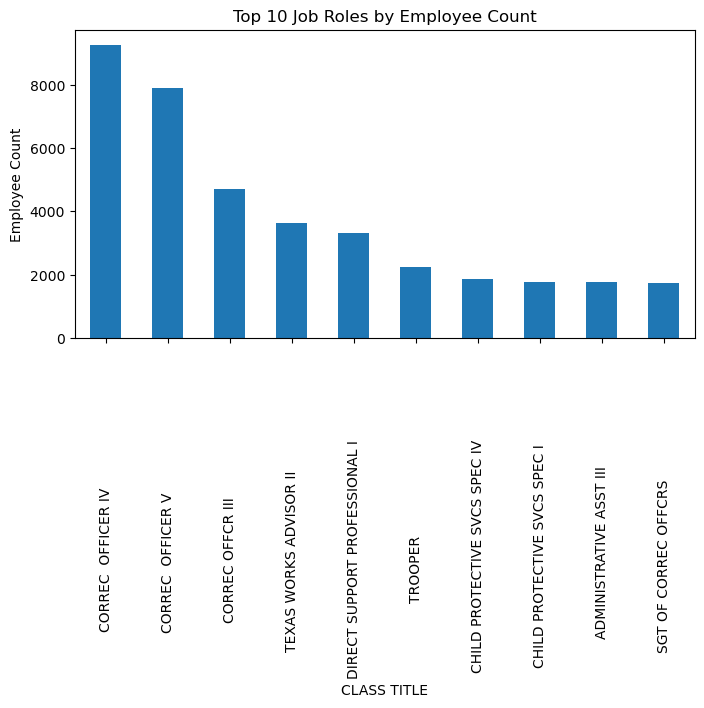

In [36]:
plt.figure(figsize=(8,4))
data['CLASS TITLE'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Job Roles by Employee Count")
plt.ylabel("Employee Count")
plt.show()

**These are the top 10 roles that employ a large portion of the workforce, where the CORREC  OFFICER IV role has 9267 employees and CORREC  OFFICER V with 7895 employees at the second place, followed by others.**

### ETHNICITY

In [37]:
data["ETHNICITY"].value_counts()

ETHNICITY
WHITE              67142
HISPANIC           40585
BLACK              35853
ASIAN               4268
OTHER                921
AM INDIAN            712
Name: count, dtype: int64

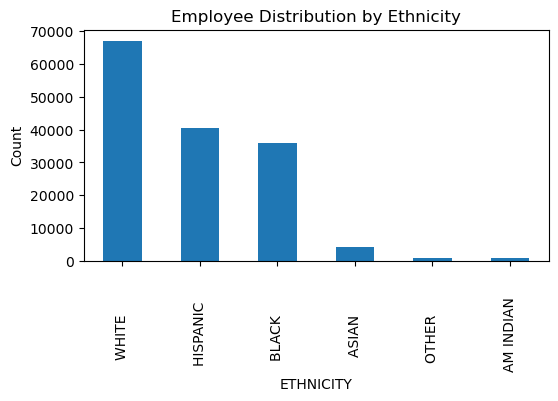

In [38]:
plt.figure(figsize=(6,3))
data['ETHNICITY'].value_counts().plot(kind='bar')
plt.title("Employee Distribution by Ethnicity")
plt.ylabel("Count")
plt.show()

**By this we can say that most employees are WHITE people with the maximum number of 67142 employees followed by HISPANIC with the number of 40585 employees and then BLACK with the number of 35853 employees at the third place and so on.**

**This analysis is descriptive and does not suggest any salary-related conclusions.**

### GENDER

In [39]:
data['GENDER'].value_counts()

GENDER
FEMALE             85328
MALE               64153
Name: count, dtype: int64

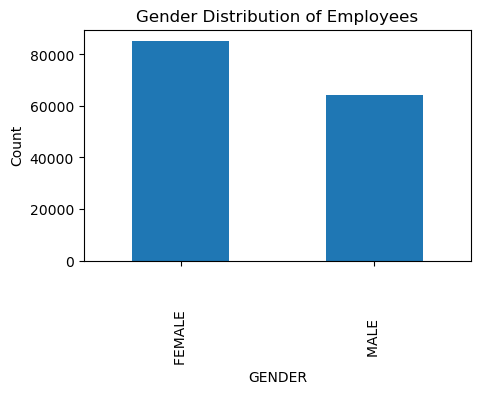

In [40]:
plt.figure(figsize=(5,3))
data['GENDER'].value_counts().plot(kind='bar')
plt.title("Gender Distribution of Employees")
plt.ylabel("Count")
plt.show()

**More employees are FEMALE individuals.**

### STATUS

In [41]:
data['STATUS'].value_counts(normalize=True)

STATUS
CRF - CLASSIFIED REGULAR FULL-TIME          0.953312
URF - UNCLASSIFIED REGULAR FULL-TIME        0.015808
CRP - CLASSIFIED REGULAR PART-TIME          0.010242
CTF - CLASSIFIED TEMPORARY FULL-TIME        0.007332
URP - UNCLASSIFIED REGULAR PART-TIME        0.006355
ERF - EXEMPT REGULAR FULL-TIME              0.006175
CTP - CLASSIFIED TEMPORARY PART-TIME        0.000542
UTP - UNCLASSIFIED TEMPORARY PART-TIME      0.000140
UTF - UNCLASSIFIED TEMPORARY FULL-TIME      0.000080
CTP - CLASSIFIED TEMPORARY FULL-TIME        0.000007
ERP - EXEMPT REGULAR PART-TIME              0.000007
Name: proportion, dtype: float64

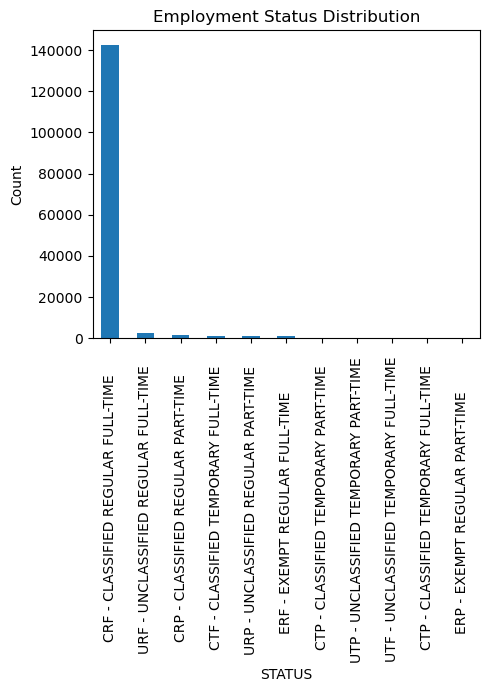

In [42]:
plt.figure(figsize=(5,4))
data['STATUS'].value_counts().plot(kind='bar')
plt.title("Employment Status Distribution")
plt.ylabel("Count")
plt.show()

**The majortiy of employees are full-time (CRF - CLASSIFIED REGULAR FULL-TIME), while a smaller portion are part-time or contractual employees. Employment status can influencee salary structure and working hours.**

### HRLY RATE

In [43]:
data['HRLY RATE'].describe()

count    149481.000000
mean          0.346488
std           4.211485
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         117.788480
Name: HRLY RATE, dtype: float64

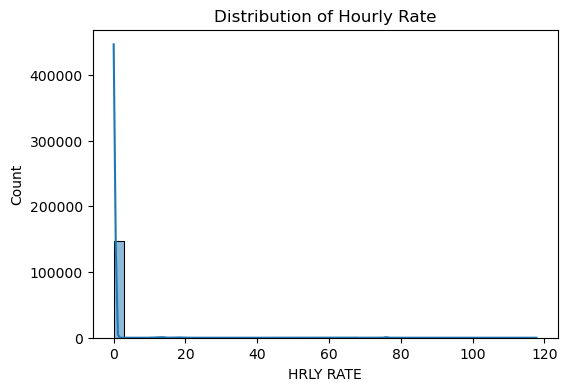

In [44]:
plt.figure(figsize=(6,4))
sns.histplot(data['HRLY RATE'], bins=40, kde=True)
plt.title("Distribution of Hourly Rate")
plt.show()

In [45]:
data['HRLY RATE'].value_counts(normalize=True).head(20)

HRLY RATE
0.00000     0.988306
75.96150    0.002161
18.00000    0.000696
19.00000    0.000636
67.30765    0.000495
12.50000    0.000442
13.50000    0.000428
13.75000    0.000421
14.00000    0.000375
17.25000    0.000348
10.71000    0.000341
18.25000    0.000308
12.85000    0.000261
17.45717    0.000254
13.57000    0.000254
16.75000    0.000254
12.00000    0.000227
12.91000    0.000207
11.50000    0.000181
13.42000    0.000174
Name: proportion, dtype: float64

**In HRLY RATE column we can see that more than 98% of the values are 0.00 which will be treated in the feature engineering part. Also we can see that the hourly rate is highly right-skewed, meaning most employees earn a moderate hourly wage, while a few earn significantly higher rates.**

### HRS PER WK

In [46]:
data['HRS PER WK'].value_counts()

HRS PER WK
40.00    146872
20.00      1339
29.00       397
30.00       210
19.00       148
35.00       123
36.25        78
24.00        78
10.00        31
25.00        25
32.00        21
16.00        21
4.00         14
8.00         12
15.00        11
36.24         8
39.60         8
50.00         8
60.00         6
41.00         5
5.00          5
12.00         5
19.20         5
70.00         4
18.00         4
36.00         3
28.00         3
6.00          2
27.00         2
26.00         2
55.00         2
1.00          2
23.20         2
7.00          1
11.00         1
22.50         1
5.20          1
4.15          1
3.35          1
8.40          1
26.93         1
29.30         1
19.04         1
13.50         1
38.80         1
19.60         1
36.21         1
21.76         1
33.00         1
31.28         1
13.88         1
30.60         1
30.40         1
20.92         1
14.00         1
17.20         1
22.00         1
23.00         1
Name: count, dtype: int64

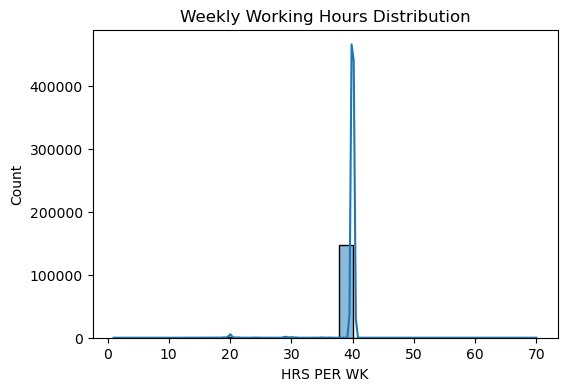

In [47]:
plt.figure(figsize=(6,4))
sns.histplot(data['HRS PER WK'], bins=30, kde=True)
plt.title("Weekly Working Hours Distribution")
plt.show()

**The majority number of employees work on an avearge of 40 hours per week, indicating that full-time employment is dominant in the dataset. The data is left skewed**

### MONTHLY

In [48]:
data['MONTHLY'].describe()

count    149481.000000
mean       4226.184248
std        2093.111691
min          50.000000
25%        3019.840000
50%        3720.170000
75%        4865.810000
max       46125.000000
Name: MONTHLY, dtype: float64

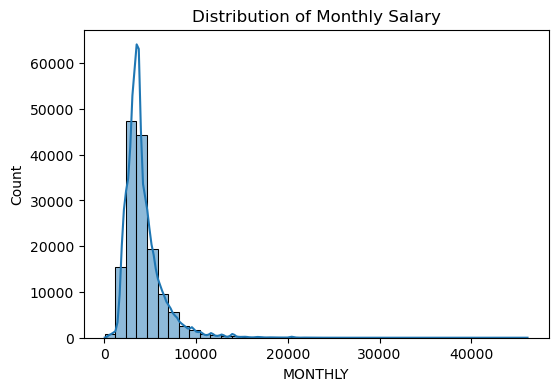

In [49]:
plt.figure(figsize=(6,4))
sns.histplot(data['MONTHLY'], bins=40, kde=True)
plt.title("Distribution of Monthly Salary")
plt.show()

**The majority of employees earn less than 10000 dollars per month.**
**Monthly salary shows a right-skewed pattern, where most employees earn within a fixed range, and fewer employees receive very high monthly compensation.**

### ANNUAL (Target Variable)

In [50]:
data['ANNUAL'].describe()

count    149481.000000
mean      50714.210973
std       25117.340292
min         600.000000
25%       36238.080000
50%       44642.040000
75%       58389.720000
max      553500.000000
Name: ANNUAL, dtype: float64

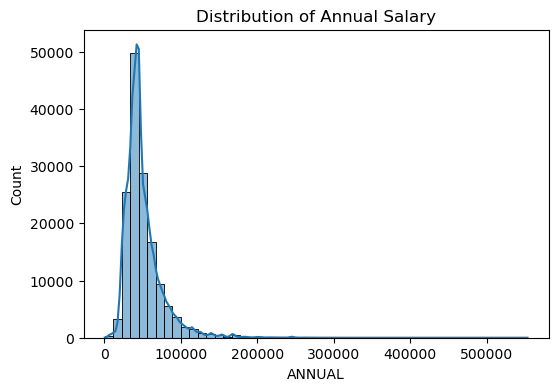

In [51]:
plt.figure(figsize=(6,4))
sns.histplot(data['ANNUAL'], bins=50, kde=True)
plt.title("Distribution of Annual Salary")
plt.show()

**Annual salary distribution is highly right-skewed. Most employees earn moderate salaries, usually less than 200000 while a small group earns significantly higher annual compensation, indicating the presence of outliers in the ANNUAL column.**

### experience_years

In [52]:
data['experience_years'].describe()


count    149481.000000
mean         12.458179
std           6.791213
min           6.000000
25%           8.000000
50%          10.000000
75%          16.000000
max          50.000000
Name: experience_years, dtype: float64

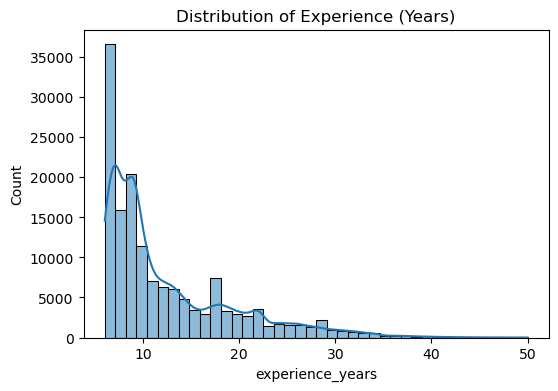

In [53]:
plt.figure(figsize=(6,4))
sns.histplot(data['experience_years'], bins=40, kde=True)
plt.title("Distribution of Experience (Years)")
plt.show()


**The majority of employees have years of experience ranges from 7 to 10 years. Most employees have mid-level experience, while fewer employees fall into very low or very high experience ranges.**

## Bi- Variate Analysis

### AGENCY NAME vs ANNUAL

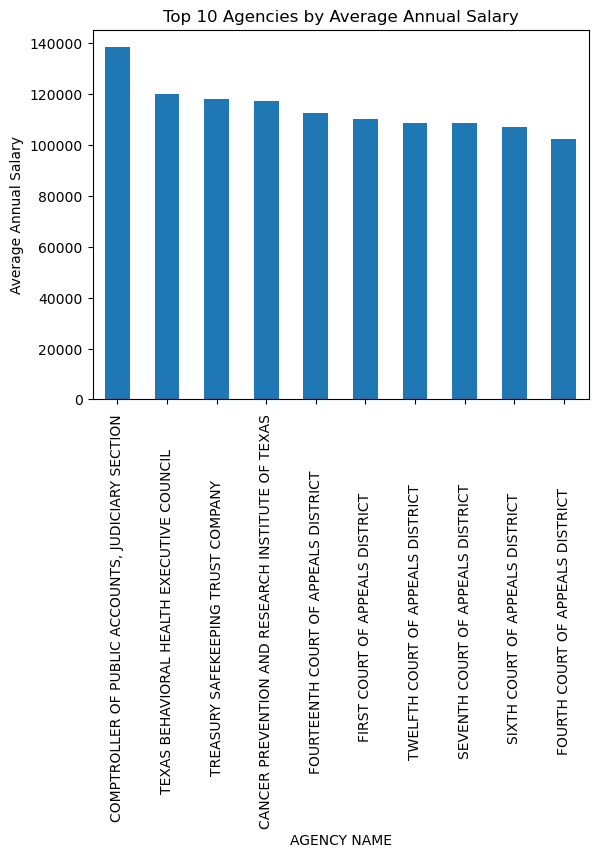

In [54]:
data.groupby('AGENCY NAME')['ANNUAL'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Agencies by Average Annual Salary")
plt.ylabel("Average Annual Salary")
plt.show()

**The salary levels strongly depend on the department and the type of work performed in that agency.**

### CLASS TITLE vs ANNUAL

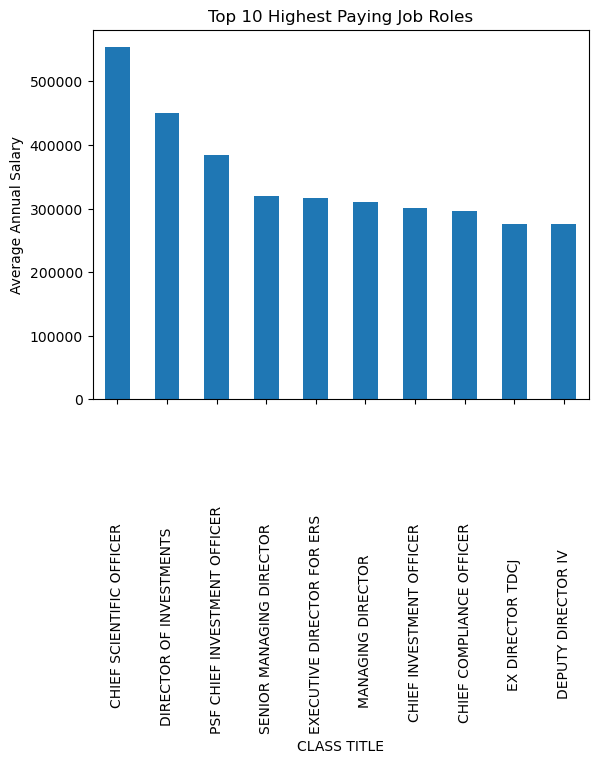

In [55]:
data.groupby('CLASS TITLE')['ANNUAL'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Highest Paying Job Roles")
plt.ylabel("Average Annual Salary")
plt.show()

**Job role has a major impact on salary. Senior, specialized, or leadership roles earn much higher salaries compared to regular operational roles.**

### ETHNICITY, GENDER vs ANNUAL

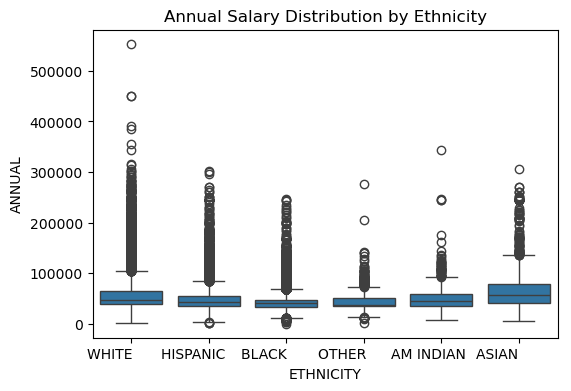

In [56]:
plt.figure(figsize=(6,4))
sns.boxplot(x='ETHNICITY', y='ANNUAL', data=data)
plt.title("Annual Salary Distribution by Ethnicity")
plt.show()

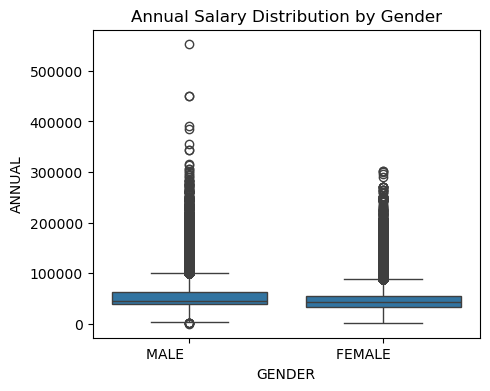

In [57]:
plt.figure(figsize=(5,4))
sns.boxplot(x='GENDER', y='ANNUAL', data=data)
plt.title("Annual Salary Distribution by Gender")
plt.show()

**Salary ranges overlap across different ethnic groups. Differences observed here are descriptive only and may be influenced by role, experience, and department rather than ethnicity itself.**

**The salary distributions for different genders largely overlap. Any visible difference in salary is likely influenced by job role, experience, and agency rather than gender alone.**

### STATUS vs ANNUAL

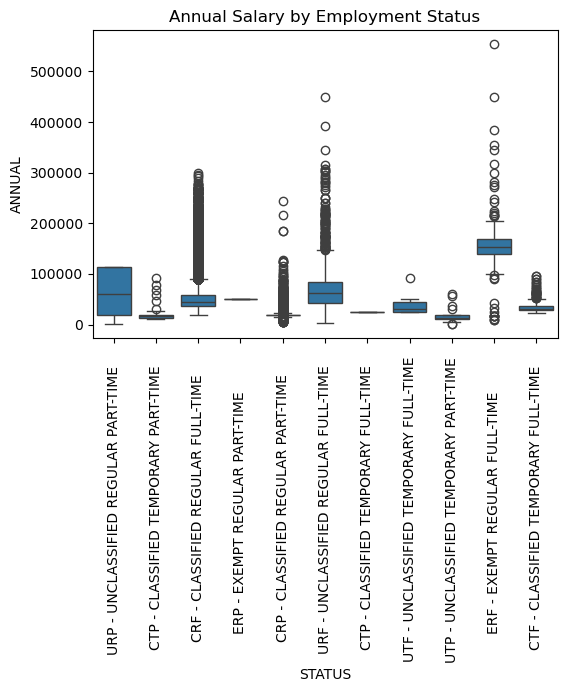

In [58]:
plt.figure(figsize=(6,4))
sns.boxplot(x='STATUS', y='ANNUAL', data=data)
plt.title("Annual Salary by Employment Status")
plt.xticks(rotation=90)
plt.show()

**Full-time employees generally earn higher annual salaries compared to part-time or contractual employees, mainly due to longer working hours and permanent roles.**

### EMPLOY DATE vs ANNUAL (Time Trend)

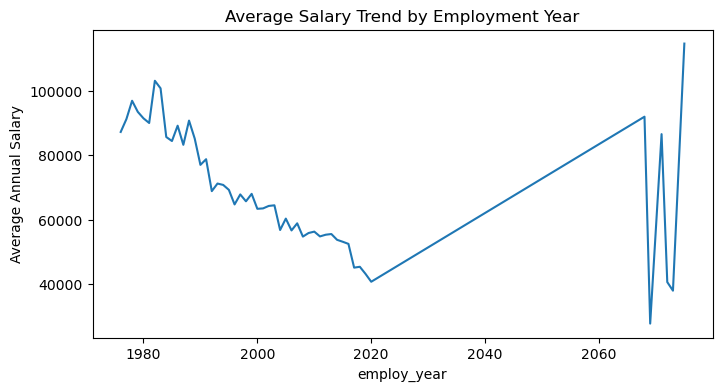

In [59]:
data['employ_year'] = data['EMPLOY DATE'].dt.year

plt.figure(figsize=(8,4))
data.groupby('employ_year')['ANNUAL'].mean().plot()
plt.title("Average Salary Trend by Employment Year")
plt.ylabel("Average Annual Salary")
plt.show()

**Employees hired earlier tend to earn higher salaries, indicating that longer tenure and experience contribute positively to salary growth over time.**

### HRLY RATE vs ANNUAL

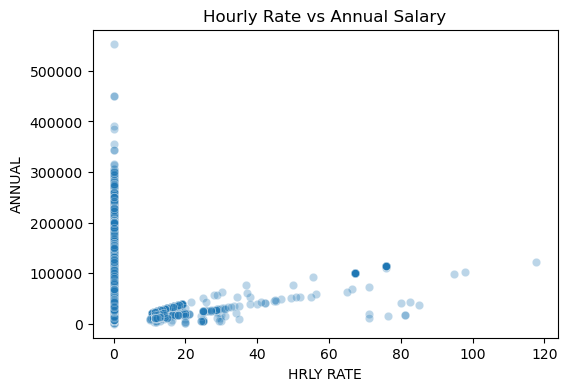

In [60]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='HRLY RATE', y='ANNUAL', data=data, alpha=0.3)
plt.title("Hourly Rate vs Annual Salary")
plt.show()

**As the HRLY RATE column has more than 98% values 0, we cant get any proper insight from them. The correlation between the HRLY RATE and ANNUAL is nearly 0.**

### HRS PER WK vs ANNUAL

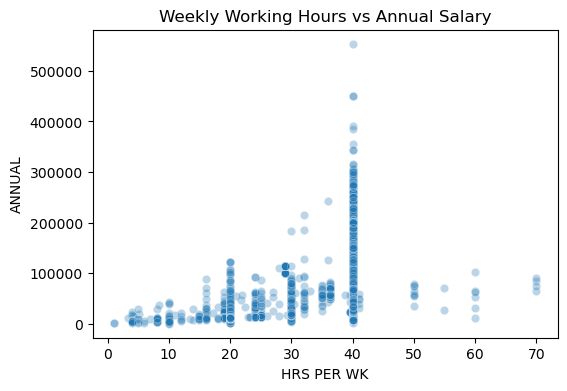

In [61]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='HRS PER WK', y='ANNUAL', data=data, alpha=0.3)
plt.title("Weekly Working Hours vs Annual Salary")
plt.show()

**Employees working more hours per week, specially 40hrs, generally earn higher annual salaries.**

### MONTHLY vs ANNUAL

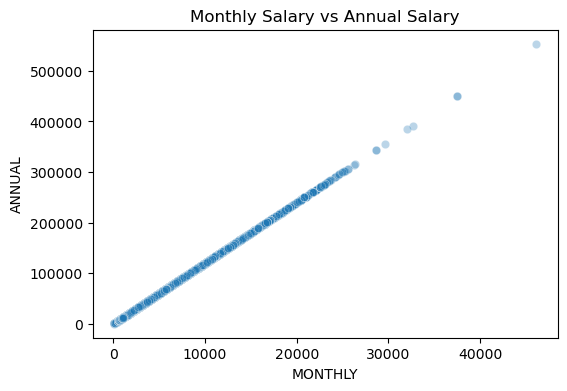

In [62]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='MONTHLY', y='ANNUAL', data=data, alpha=0.3)
plt.title("Monthly Salary vs Annual Salary")
plt.show()

**By this we can see that the MONTHLY column has very strong linear relationship with the ANNUAL column. We will be using this MONTHLY column only for the report and EDA purpose because if we use this column for the model building then it will cause the direct data leakage, because the monthly salary is itself derived from annual compensation. The model will just learn the simple multiplication and give the artificial high R² score/low error, but the model will fail in real world predction.**

**Any column that is a direct or near-direct mathematical transformation of the target must be removed from X.**

### EXPERIENCE YEARS vs ANNUAL

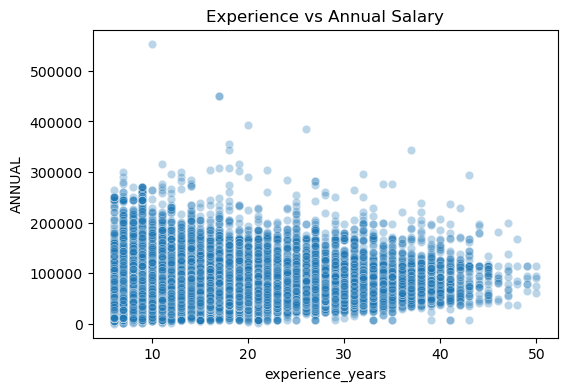

In [63]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='experience_years', y='ANNUAL', data=data, alpha=0.3)
plt.title("Experience vs Annual Salary")
plt.show()

**Salary generally increases with experience. However, the wide spread shows that experience alone does not determine salary; job role and department also play an important role.**

### Identifying Salary Outliers

In [64]:
Q1 = data['ANNUAL'].quantile(0.25)
Q3 = data['ANNUAL'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[(data["ANNUAL"] < lower_bound) | (data["ANNUAL"] > upper_bound)]

In [65]:
outliers

,AGENCY,AGENCY NAME,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,EMPLOY DATE,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,experience_years,employ_year
0,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,1988-02-18,75.9615,29.0,9545.82,114549.84,38.0,1988
2,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,2020-02-01,75.9615,29.0,9545.82,114549.84,6.0,2020
5,302,OFFICE OF THE ATTORNEY GENERAL ...,1623,DIRECTOR IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,2020-04-01,0.0000,40.0,12899.00,154788.00,6.0,2020
7,510,TEXAS BEHAVIORAL HEALTH EXECUTIVE COUNCIL ...,1623,DIRECTOR IV ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,2020-03-01,0.0000,40.0,10000.00,120000.00,6.0,2020
36,101,SENATE ...,7101,LEG. OFFICIAL/ADMINISTRATOR ...,WHITE,FEMALE,URF - UNCLASSIFIED REGULAR FULL-TIME,2010-07-26,0.0000,40.0,8000.00,96000.00,16.0,2010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149374,809,STATE PRESERVATION BOARD ...,1623,DIRECTOR IV ...,WHITE,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,2013-01-23,0.0000,40.0,10583.34,127000.08,13.0,2013
149393,809,STATE PRESERVATION BOARD ...,1603,MGR IV ...,HISPANIC,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,2004-03-15,0.0000,40.0,8358.41,100300.92,22.0,2004
149401,809,STATE PRESERVATION BOARD ...,1602,MGR III ...,BLACK,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,2005-10-12,0.0000,40.0,7916.67,95000.04,21.0,2005
149415,809,STATE PRESERVATION BOARD ...,1622,DIRECTOR III ...,WHITE,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,2008-12-02,0.0000,40.0,10188.09,122257.08,18.0,2008


### Outliers by Role & Agency

In [66]:
outliers[['CLASS TITLE', 'AGENCY NAME', 'ANNUAL']].sort_values(
    by='ANNUAL', ascending=False
).head(10)

,CLASS TITLE,AGENCY NAME,ANNUAL
83851,CHIEF SCIENTIFIC OFFICER ...,CANCER PREVENTION AND RESEARCH INSTITUTE OF TE...,553500.00
14793,CHIEF INVESTMENT OFFICER ...,TEACHER RETIREMENT SYSTEM ...,450000.00
144232,DIRECTOR OF INVESTMENTS ...,EMPLOYEES RETIREMENT SYSTEM ...,450000.00
15154,SENIOR MANAGING DIRECTOR ...,TEACHER RETIREMENT SYSTEM ...,391999.92
136727,PSF CHIEF INVESTMENT OFFICER ...,TEXAS EDUCATION AGENCY ...,384375.00
15041,EXECUTIVE DIRECTOR ...,TEACHER RETIREMENT SYSTEM ...,355141.44
15539,SENIOR MANAGING DIRECTOR ...,TEACHER RETIREMENT SYSTEM ...,344000.04
84769,EXECUTIVE DIRECTOR ...,TEXAS DEPARTMENT OF TRANSPORTATION ...,343999.92
144262,EXECUTIVE DIRECTOR FOR ERS ...,EMPLOYEES RETIREMENT SYSTEM ...,316116.96
15349,MANAGING DIRECTOR ...,TEACHER RETIREMENT SYSTEM ...,315000.00


**The outliers are detetcted using the IQR method. Salary outliers are mainly employees working in senior, leadership, or highly specialized roles. These employees earn significantly more than the majority of the workforce and are usually concentrated in specific agencies.**

### Departments/roles having the biggest wage disparities between Managers and Employees

In [67]:
#Since we don’t have a direct manager flag, we use job title logic.
data['is_manager'] = data['CLASS TITLE'].str.contains(
    'MANAGER|DIRECTOR|CHIEF|HEAD|SUPERVISOR',
    case=False,
    na=False
)

In [68]:
manager_salary = data.groupby('is_manager')['ANNUAL'].mean() #getting the average annual salary of managers and non-managers employees
manager_salary

is_manager
False    48771.175559
True     87466.469560
Name: ANNUAL, dtype: float64

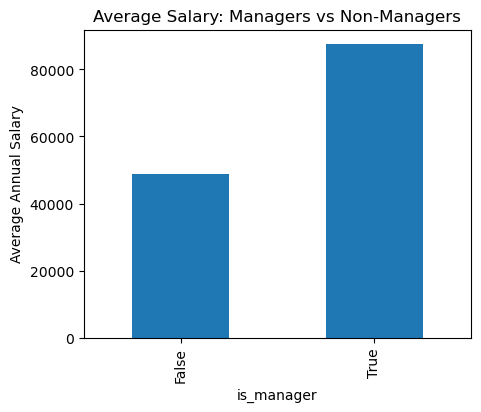

In [69]:
manager_salary.plot(kind='bar', figsize=(5,4))
plt.title("Average Salary: Managers vs Non-Managers")
plt.ylabel("Average Annual Salary")
plt.show()

**Managers earn significantly higher salaries than non-manager employees.**

### Wage gap by Department

In [70]:
dept_gap = (data.groupby(['is_manager', 'AGENCY NAME'])['ANNUAL'].mean().unstack(level="is_manager")) 
#this unstack will make the values of that column as seperate columns so that we can easily compare and substract and get the difference

In [71]:
dept_gap

is_manager,False,True
AGENCY NAME,,
ALCOHOLIC BEVERAGE COMMISSION,58186.215754,124199.419200
BOARD OF ARCHITECTURAL EXAMINERS,75125.086667,145604.640000
BOARD OF CHIROPRACTIC EXAMINERS,59073.386667,100830.000000
BOARD OF DENTAL EXAMINERS,50648.692075,97333.320000
BOARD OF EXAMINERS OF PSYCHOLOGISTS,46863.136000,NaN
...,...,...
THIRD COURT OF APPEALS DISTRICT,92608.308387,187800.000000
THIRTEENTH COURT OF APPEALS DISTRICT,96848.544828,187800.000000
TREASURY SAFEKEEPING TRUST COMPANY,95037.450000,165747.855652


In [72]:
dept_gap['salary_gap'] = dept_gap[True] - dept_gap[False] #calculating the gap by substracting manager vs non-manager.

In [73]:
dept_gap.sort_values(by='salary_gap', ascending=False).head(5) #getting the top 5 departments with highest wage difference between manager and employees

is_manager,False,True,salary_gap
AGENCY NAME,,,
CANCER PREVENTION AND RESEARCH INSTITUTE OF TEXAS,72609.621818,206399.138182,133789.516364
THIRD COURT OF APPEALS DISTRICT,92608.308387,187800.000000,95191.691613
SECOND COURT OF APPEALS DISTRICT,93137.108571,187800.000000,94662.891429
TEACHER RETIREMENT SYSTEM,78192.117214,170189.109882,91996.992669
NINTH COURT OF APPEALS DISTRICT,95892.942000,187800.000000,91907.058000


**Above are the departments having the biggest wage disparities between managers and employees.**

### Have salaries changed over time?

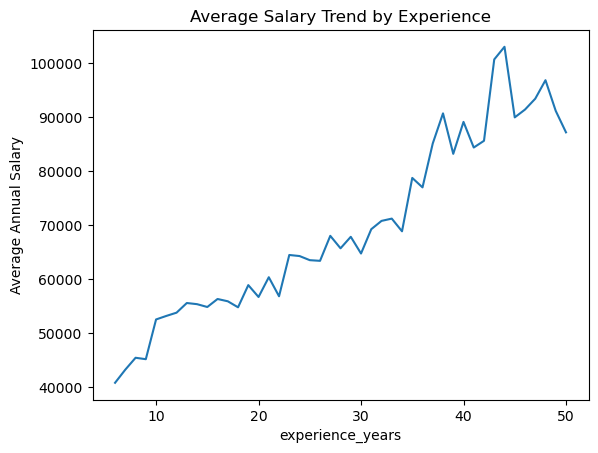

In [74]:
data.groupby('experience_years')['ANNUAL'].mean().plot()
plt.title("Average Salary Trend by Experience")
plt.ylabel("Average Annual Salary")
plt.show()

**Average salary increases steadily with experience. Employees with more years of service tend to earn higher salaries, showing gradual salary growth over time.**

## Summary

**Salary outliers are mainly found in senior and leadership roles across select agencies. Managers earn significantly higher salaries than non-manager employees, with some departments showing a larger wage gap. Salary trends indicate a clear increase with experience and longer tenure, suggesting structured salary growth over time.**

In [75]:
data.columns

Index(['AGENCY', 'AGENCY NAME', 'CLASS CODE', 'CLASS TITLE', 'ETHNICITY',
       'GENDER', 'STATUS', 'EMPLOY DATE', 'HRLY RATE', 'HRS PER WK', 'MONTHLY',
       'ANNUAL', 'experience_years', 'employ_year', 'is_manager'],
      dtype='object')

## Feature Selection/Feature-Engineering/Data Pre-Processing

- **We will keep "AGENCY NAME" and drop "AGENCY" COLUMN as both tells the same information so we will keep any one.**
- **We will keep "CLASS TITLE" and drop "CLASS CODE" COLUMN as both tells the same information so we will keep any one.**
  - **After dropping the "CLASS CODE" and "AGENCY" column we will perform Target encoding with smoothing.** 
- **Sensitive attributes should be used for fairness analysis and EDA purpose, not for prediction, so we are dropping the "GENDER" and "ETHNICITY" column.**
- **"STATUS" column will be one-hot encoded.**
- **Will drop "EMPLOY DATE" as the relevant infomation has been extracted from it by creating the "experience_years" column.**
- **Will drop "HRLY RATE" column, we have two valid reasons for dropping it:**
  - **More than 98% of values are 0 which dosen't make any sense because employee with HRLY RATE = 0 dosen't means that employee is for free.**
  - **We also have a logical reason to drop this as out dataset has more than 95% employees who are regular full time employees and for  full time employees the salary is fixed and HRLY RATE is not applicable.**
- **Will keep the "HRS PER WK" as a numeric column while building the model.**
- **Will drop the "MONTHLY" column because if we use this column for the model building then it will cause the direct data leakage, because the monthly salary is itself derived from annual compensation. The model will just learn the simple multiplication and give the artificial high R² score/low error, but the model will fail in real world predction.**
- **ANNUAL column is our Target column will assign it to variable y.**
- **We will keep the 'is_manager' column and change its datatype to integer, as it can be a strong predictive feature.**

### One-Hot Encoding STATUS column

In [76]:
data = pd.get_dummies(data, columns=['STATUS'], drop_first=True, dtype="int")

In [77]:
data

,AGENCY,AGENCY NAME,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,EMPLOY DATE,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,experience_years,employ_year,is_manager,STATUS_CRP - CLASSIFIED REGULAR PART-TIME,STATUS_CTF - CLASSIFIED TEMPORARY FULL-TIME,STATUS_CTP - CLASSIFIED TEMPORARY FULL-TIME,STATUS_CTP - CLASSIFIED TEMPORARY PART-TIME,STATUS_ERF - EXEMPT REGULAR FULL-TIME,STATUS_ERP - EXEMPT REGULAR PART-TIME,STATUS_URF - UNCLASSIFIED REGULAR FULL-TIME,STATUS_URP - UNCLASSIFIED REGULAR PART-TIME,STATUS_UTF - UNCLASSIFIED TEMPORARY FULL-TIME,STATUS_UTP - UNCLASSIFIED TEMPORARY PART-TIME
0,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",JD25,"JUDGE, RETIRED ...",WHITE,MALE,1988-02-18,75.96150,29.0,9545.82,114549.84,38.0,1988,False,0,0,0,0,0,0,0,1,0,0
1,212,OFFICE OF COURT ADMINISTRATION ...,3524,GENERAL COUNSEL IV ...,WHITE,MALE,2015-02-01,81.04454,4.0,1404.77,16857.24,11.0,2015,False,0,0,0,1,0,0,0,0,0,0
2,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",JD25,"JUDGE, RETIRED ...",WHITE,MALE,2020-02-01,75.96150,29.0,9545.82,114549.84,6.0,2020,False,0,0,0,0,0,0,0,1,0,0
3,212,OFFICE OF COURT ADMINISTRATION ...,3524,GENERAL COUNSEL IV ...,WHITE,MALE,2018-09-01,81.04453,4.0,1404.77,16857.24,8.0,2018,False,0,0,0,1,0,0,0,0,0,0
4,696,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,4504,CORREC OFFICER IV ...,HISPANIC,FEMALE,2020-06-29,0.00000,40.0,3284.27,39411.24,6.0,2020,False,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149476,809,STATE PRESERVATION BOARD ...,6232,SECURITY OFFICER III ...,WHITE,MALE,2017-10-30,0.00000,40.0,2899.00,34788.00,9.0,2017,False,0,0,0,0,0,0,0,0,0,0
149477,809,STATE PRESERVATION BOARD ...,0302,WEB ADMINISTRATOR III ...,WHITE,FEMALE,2015-07-13,0.00000,40.0,5500.00,66000.00,11.0,2015,False,0,0,0,0,0,0,0,0,0,0
149478,809,STATE PRESERVATION BOARD ...,0130,CUSTOMER SERVICE REP I ...,WHITE,MALE,2012-10-15,12.93000,20.0,1120.60,13447.20,14.0,2012,False,1,0,0,0,0,0,0,0,0,0
149479,809,STATE PRESERVATION BOARD ...,1572,PROGRAM SPECIALIST III ...,WHITE,MALE,1989-09-22,0.00000,40.0,5744.16,68929.92,37.0,1989,False,0,0,0,0,0,0,0,0,0,0


In [78]:
data.columns

Index(['AGENCY', 'AGENCY NAME', 'CLASS CODE', 'CLASS TITLE', 'ETHNICITY',
       'GENDER', 'EMPLOY DATE', 'HRLY RATE', 'HRS PER WK', 'MONTHLY', 'ANNUAL',
       'experience_years', 'employ_year', 'is_manager',
       'STATUS_CRP - CLASSIFIED REGULAR PART-TIME      ',
       'STATUS_CTF - CLASSIFIED TEMPORARY FULL-TIME    ',
       'STATUS_CTP - CLASSIFIED TEMPORARY FULL-TIME    ',
       'STATUS_CTP - CLASSIFIED TEMPORARY PART-TIME    ',
       'STATUS_ERF - EXEMPT REGULAR FULL-TIME          ',
       'STATUS_ERP - EXEMPT REGULAR PART-TIME          ',
       'STATUS_URF - UNCLASSIFIED REGULAR FULL-TIME    ',
       'STATUS_URP - UNCLASSIFIED REGULAR PART-TIME    ',
       'STATUS_UTF - UNCLASSIFIED TEMPORARY FULL-TIME  ',
       'STATUS_UTP - UNCLASSIFIED TEMPORARY PART-TIME  '],
      dtype='object')

In [79]:
#changing the data type of "is_manager" column from Boolean to Integer.
data.is_manager = data["is_manager"].astype("int32")

In [80]:
cols_to_drop = ['AGENCY',
    'CLASS CODE',
    'ETHNICITY',
    'GENDER',
    'EMPLOY DATE',
    'HRLY RATE',
    'MONTHLY',
    'ANNUAL',
    'employ_year']

### Splitting the Input Features and Target Column

In [81]:
X = data.drop(columns=cols_to_drop)
y = data['ANNUAL']

In [82]:
X.columns

Index(['AGENCY NAME', 'CLASS TITLE', 'HRS PER WK', 'experience_years',
       'is_manager', 'STATUS_CRP - CLASSIFIED REGULAR PART-TIME      ',
       'STATUS_CTF - CLASSIFIED TEMPORARY FULL-TIME    ',
       'STATUS_CTP - CLASSIFIED TEMPORARY FULL-TIME    ',
       'STATUS_CTP - CLASSIFIED TEMPORARY PART-TIME    ',
       'STATUS_ERF - EXEMPT REGULAR FULL-TIME          ',
       'STATUS_ERP - EXEMPT REGULAR PART-TIME          ',
       'STATUS_URF - UNCLASSIFIED REGULAR FULL-TIME    ',
       'STATUS_URP - UNCLASSIFIED REGULAR PART-TIME    ',
       'STATUS_UTF - UNCLASSIFIED TEMPORARY FULL-TIME  ',
       'STATUS_UTP - UNCLASSIFIED TEMPORARY PART-TIME  '],
      dtype='object')

### Train-test Split

In [83]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

### Target encode AGENCY NAME and CLASS TITLE

In [84]:
!pip install category_encoders

In [85]:
from category_encoders import TargetEncoder

In [86]:
te = TargetEncoder(cols=['AGENCY NAME', 'CLASS TITLE'],smoothing=10)
X_train = te.fit_transform(X_train, y_train)
X_test = te.transform(X_test)

### Applying Standard Scaler

In [87]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [88]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)

X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

# Building Model

## Linear Regression

In [89]:
from sklearn.linear_model import LinearRegression

LR = LinearRegression()
LR.fit(X_train_scaled, y_train)

LinearRegression()

### Making Predictions

In [90]:
y_train_pred = LR.predict(X_train_scaled)
y_test_pred = LR.predict(X_test_scaled)

### Model Evaluation

#### r2 score

In [91]:
from sklearn.metrics import mean_squared_error, r2_score
r2_train = r2_score(y_train, y_train_pred)

In [92]:
r2_test = r2_score(y_test, y_test_pred)

In [93]:
print(f"Train R²  : {r2_train:.4f}")
print(f"Test R²   : {r2_test:.4f}")

Train R²  : 0.8692
Test R²   : 0.8406


#### RSME

In [94]:
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))

In [95]:
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

In [96]:
print(f"Train RMSE: {rmse_train:.2f}")
print(f"Test RMSE : {rmse_test:.2f}")

Train RMSE: 9064.23
Test RMSE : 10119.98


#### Adjusted r2 score

In [97]:
n = X_test_scaled.shape[0]   # number of samples
p = X_test_scaled.shape[1]   # number of features

In [98]:
adjusted_r2 = 1 - (1 - r2_test) * (n - 1) / (n - p - 1)
print(f"Adjusted R²: {adjusted_r2:.4f}")

Adjusted R²: 0.8405


## Random Forest

In [99]:
X_train_tree = X_train.copy()
X_test_tree = X_test.copy()

In [100]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=30,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_tree, y_train)

y_train_pred_rf = rf.predict(X_train_tree)
y_test_pred_rf = rf.predict(X_test_tree)

print("Random Forest Train R²:", r2_score(y_train, y_train_pred_rf))
print("Random Forest Test  R²:", r2_score(y_test, y_test_pred_rf))

Random Forest Train R²: 0.9133702688210437
Random Forest Test  R²: 0.8782377427750949


In [101]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr.fit(X_train_tree, y_train)

y_test_pred_gbr = gbr.predict(X_test_tree)
print("Gradient Boosting Test R²:", r2_score(y_test, y_test_pred_gbr))

Gradient Boosting Test R²: 0.8885850693014464


# Model Evaluation Summary

**Three different models were trained and evaluated to predict the annual salary of Texas state employees: Linear Regression, Random Forest, and Gradient Boosting. The models were compared using R² score on the test dataset to assess their performance.**

  - ### Linear Regression

**The linear regression model served as a baseline model. It achieved a test R² of approximately 0.84, indicating that it explains about 84% of the variance in annual salary.**

  - ### Random Forest Regressor

**The Random Forest model improved upon the linear baseline, achieving a test R² of approximately 0.88.**

  - ### Gradient Boosting Regressor

**The Gradient Boosting model delivered the best performance, with a test R² of approximately 0.89. Given its strong performance, Gradient Boosting was selected as the final model for further optimization.**

# Conclusion

  - **Linear Regression provided a strong and interpretable baseline.**

  - **Tree-based models outperformed the linear model, confirming the presence of non-linear effects.**

  - **Gradient Boosting achieved the highest predictive performance and was chosen for hyperparameter tuning to further improve results.**

# Hyperparameter Tuning

In [102]:
from sklearn.model_selection import RandomizedSearchCV

In [103]:
param_grid_small = {
    'n_estimators': [200, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3],
    'min_samples_leaf': [30, 50],
    'subsample': [0.8]
}

In [104]:
random_search = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_distributions=param_grid_small,
    n_iter=30,          # only try 30 combinations
    scoring='r2',
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=3
)

In [105]:
random_search.fit(X_train_tree, y_train)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


RandomizedSearchCV(cv=3, estimator=GradientBoostingRegressor(random_state=42),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'learning_rate': [0.05, 0.1],
                                        'max_depth': [2, 3],
                                        'min_samples_leaf': [30, 50],
                                        'n_estimators': [200, 300],
                                        'subsample': [0.8]},
                   random_state=42, scoring='r2', verbose=3)

In [106]:
print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'subsample': 0.8, 'n_estimators': 300, 'min_samples_leaf': 30, 'max_depth': 3, 'learning_rate': 0.1}


# Fitting the tuned model

In [107]:
tuned_gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=3,
    min_samples_leaf=30,
    subsample=0.8,
    random_state=42
)

tuned_gbr.fit(X_train_tree, y_train)

y_test_pred_gbr_tuned = tuned_gbr.predict(X_test_tree)
print("Gradient Boosting Test R²:", r2_score(y_test, y_test_pred_gbr_tuned))

Gradient Boosting Test R²: 0.8954438068885104


In [108]:
import pickle

# Assuming 'gbr_tuned' is the name of your final tuned model object
model_filename = 'Gradient_Boosting_Regressor_Model.pkl'

# Save the model to a pickle file
with open(model_filename, 'wb') as file:
    pickle.dump(tuned_gbr, file)

print(f"Model saved successfully as {model_filename}")

Model saved successfully as Gradient_Boosting_Regressor_Model.pkl


# Conclusion

**After performing the hyperparameter tuning for Gradient Boosting Regressor model we saw a slight improvement in the r2 score - 0.90 indicating that it explains about 90% of the variance in annual salary.**

# Final Verdict

**The project demonstrates a complete and well-structured machine learning workflow, from data preprocessing and feature engineering to model comparison, hyperparameter tuning, and final evaluation. The tuned Gradient Boosting model represents an optimal balance between performance and generalization.**